# Тонкая настройка модели CatBoost для постановки no_sleep_quality_lag

В данном ноутбуке выполняется подбор гиперпараметров модели CatBoost для задачи прогнозирования качества сна без использования прямых лагов показателя sleep_efficiency. Для обеспечения корректности оценки данные разделяются по участникам на обучающую, валидационную и тестовую выборки.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import json

sys.path.append(str(Path("..").resolve()))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier, Pool

from src.config import (
    MODEL_DATA_PATH,
    RANDOM_STATE,
    CATBOOST_MODEL_DIR,
    REPORT_TABLES_DIR,
    REPORT_TEXT_DIR,
    REPORT_LOGS_DIR,
    CM_FIG_DIR,
    FI_FIG_DIR,
)

In [14]:
model_df = pd.read_csv(MODEL_DATA_PATH)

print(model_df.shape)
print(model_df["target_bad_sleep"].value_counts(normalize=True))
model_df.head()

(47523, 82)
target_bad_sleep
0    0.627928
1    0.372072
Name: proportion, dtype: float64


,SEQN,calendar_date,weekday,dayofweek,window_number,night_number,month,day,dayofyear,target_bad_sleep,...,dur_spt_sleep_min_lag3,dur_spt_wake_IN_min_lag3,dur_spt_wake_LIG_min_lag3,dur_spt_wake_MOD_min_lag3,dur_spt_wake_VIG_min_lag3,dur_day_min_lag3,dur_spt_min_lag3,dur_day_spt_min_lag3,ACC_spt_sleep_mg_lag3,excluded_lag3
0,62161,2000-01-12,Wednesday,4,4,5,1,12,12,1,...,436.0,39.0,2.0,0.0,0.0,876.0,477.0,1353.0,6.743,0.0
1,62161,2000-01-13,Thursday,5,5,6,1,13,13,1,...,403.0,92.0,1.0,0.0,0.0,942.0,496.0,1438.0,3.550,0.0
2,62161,2000-01-14,Friday,6,6,7,1,14,14,1,...,435.0,101.0,10.0,0.0,0.0,896.0,546.0,1442.0,3.243,0.0
3,62161,2000-01-15,Saturday,7,7,8,1,15,15,1,...,425.0,108.0,5.0,0.0,0.0,902.0,538.0,1440.0,5.848,0.0
4,62163,2000-01-12,Wednesday,4,4,5,1,12,12,0,...,332.0,43.0,3.0,0.0,0.0,1004.0,378.0,1382.0,11.669,0.0


In [15]:
target_col = "target_bad_sleep"
group_col = "SEQN"

X = model_df.drop(columns=[target_col]).copy()
y = model_df[target_col].astype(int).copy()
groups = model_df[group_col].copy()

In [16]:
def select_no_sleep_quality_lag(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    drop_cols = [
        "SEQN",
        "calendar_date",
        "sleep_efficiency_lag1",
        "sleep_efficiency_lag2",
        "sleep_efficiency_lag3",
    ]

    X = X.drop(columns=[c for c in drop_cols if c in X.columns])

    return X

Разделение на train valid test

In [17]:
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_train_val = X.iloc[train_val_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train_val = y.iloc[train_val_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train_val = groups.iloc[train_val_idx]
groups_test = groups.iloc[test_idx]

print("Train+Valid:", X_train_val.shape, y_train_val.shape)
print("Test       :", X_test.shape, y_test.shape)
print("Users train+valid:", groups_train_val.nunique())
print("Users test       :", groups_test.nunique())
print("Intersection:", len(set(groups_train_val).intersection(set(groups_test))))

Train+Valid: (37976, 81) (37976,)
Test       : (9547, 81) (9547,)
Users train+valid: 10430
Users test       : 2608
Intersection: 0


In [18]:
gss_valid = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

train_idx, valid_idx = next(gss_valid.split(X_train_val, y_train_val, groups=groups_train_val))

X_train = X_train_val.iloc[train_idx].copy()
X_valid = X_train_val.iloc[valid_idx].copy()

y_train = y_train_val.iloc[train_idx].copy()
y_valid = y_train_val.iloc[valid_idx].copy()

groups_train = groups_train_val.iloc[train_idx]
groups_valid = groups_train_val.iloc[valid_idx]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

print("Users train:", groups_train.nunique())
print("Users valid:", groups_valid.nunique())
print("Users test :", groups_test.nunique())

print("Train/Valid intersection:", len(set(groups_train).intersection(set(groups_valid))))
print("Train/Test intersection :", len(set(groups_train).intersection(set(groups_test))))
print("Valid/Test intersection :", len(set(groups_valid).intersection(set(groups_test))))

Train: (30376, 81) (30376,)
Valid: (7600, 81) (7600,)
Test : (9547, 81) (9547,)
Users train: 8344
Users valid: 2086
Users test : 2608
Train/Valid intersection: 0
Train/Test intersection : 0
Valid/Test intersection : 0


In [19]:
X_train = select_no_sleep_quality_lag(X_train)
X_valid = select_no_sleep_quality_lag(X_valid)
X_test = select_no_sleep_quality_lag(X_test)

print("Train features:", X_train.shape)
print("Valid features:", X_valid.shape)
print("Test features :", X_test.shape)

Train features: (30376, 76)
Valid features: (7600, 76)
Test features : (9547, 76)


In [20]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric count:", len(numeric_cols))

Categorical: ['weekday']
Numeric count: 75


In [21]:
for col in categorical_cols:
    X_train[col] = X_train[col].fillna("missing")
    X_valid[col] = X_valid[col].fillna("missing")
    X_test[col] = X_test[col].fillna("missing")

In [22]:
def evaluate_thresholds(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.25, 0.91, 0.05)

    rows = []

    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)

        rows.append({
            "threshold": round(float(thr), 4),
            "precision": precision_score(y_true, y_pred_thr, zero_division=0),
            "recall": recall_score(y_true, y_pred_thr, zero_division=0),
            "f1": f1_score(y_true, y_pred_thr, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["f1"].idxmax()].copy()

    return threshold_df, best_row

In [23]:
param_grid = [
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 3, "iterations": 600},
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 5, "iterations": 600},
    {"depth": 4, "learning_rate": 0.10, "l2_leaf_reg": 7, "iterations": 400},

    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 3, "iterations": 800},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 5, "iterations": 600},
    {"depth": 6, "learning_rate": 0.10, "l2_leaf_reg": 7, "iterations": 400},

    {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg": 5, "iterations": 800},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg": 7, "iterations": 600},
    {"depth": 8, "learning_rate": 0.10, "l2_leaf_reg": 9, "iterations": 400},
]

In [24]:
cat_features = [X_train.columns.get_loc(col) for col in categorical_cols]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

In [25]:
tuning_rows = []
best_model = None
best_threshold_df = None
best_valid_pred = None
best_valid_proba = None
best_cfg = None
best_score = -1

for i, cfg in enumerate(param_grid, start=1):
    print(f"\n=== Config {i}/{len(param_grid)}: {cfg} ===")

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=100,
        **cfg
    )

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True
    )

    valid_proba = model.predict_proba(valid_pool)[:, 1]
    valid_auc = roc_auc_score(y_valid, valid_proba)

    threshold_df, best_row = evaluate_thresholds(y_valid, valid_proba)
    best_threshold = float(best_row["threshold"])
    valid_pred = (valid_proba >= best_threshold).astype(int)

    valid_precision = precision_score(y_valid, valid_pred, zero_division=0)
    valid_recall = recall_score(y_valid, valid_pred, zero_division=0)
    valid_f1 = f1_score(y_valid, valid_pred, zero_division=0)

    row = {
        "depth": cfg["depth"],
        "learning_rate": cfg["learning_rate"],
        "l2_leaf_reg": cfg["l2_leaf_reg"],
        "iterations": cfg["iterations"],
        "best_iteration": model.get_best_iteration(),
        "valid_roc_auc": valid_auc,
        "best_threshold": best_threshold,
        "valid_precision": valid_precision,
        "valid_recall": valid_recall,
        "valid_f1": valid_f1,
    }
    tuning_rows.append(row)

    print(pd.Series(row))

    # Основной критерий выбора — valid_f1
    if valid_f1 > best_score:
        best_score = valid_f1
        best_model = model
        best_threshold_df = threshold_df.copy()
        best_valid_pred = valid_pred.copy()
        best_valid_proba = valid_proba.copy()
        best_cfg = row.copy()


=== Config 1/9: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 600} ===
0:	test: 0.6900918	best: 0.6900918 (0)	total: 164ms	remaining: 1m 38s
100:	test: 0.7416114	best: 0.7416114 (100)	total: 2.21s	remaining: 10.9s
200:	test: 0.7460244	best: 0.7460373 (198)	total: 4.21s	remaining: 8.36s
300:	test: 0.7474584	best: 0.7474762 (299)	total: 6.26s	remaining: 6.22s
400:	test: 0.7481603	best: 0.7482024 (397)	total: 8.29s	remaining: 4.11s
500:	test: 0.7481324	best: 0.7482308 (409)	total: 10.4s	remaining: 2.05s
599:	test: 0.7482550	best: 0.7483799 (575)	total: 12.4s	remaining: 0us

bestTest = 0.7483798915
bestIteration = 575

Shrink model to first 576 iterations.
depth                4.000000
learning_rate        0.030000
l2_leaf_reg          3.000000
iterations         600.000000
best_iteration     575.000000
valid_roc_auc        0.748380
best_threshold       0.300000
valid_precision      0.509554
valid_recall         0.775862
valid_f1             0.615122
dtype: float64



In [26]:
tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["valid_f1", "valid_roc_auc"],
    ascending=False
).reset_index(drop=True)

tuning_results.round(4)

,depth,learning_rate,l2_leaf_reg,iterations,best_iteration,valid_roc_auc,best_threshold,valid_precision,valid_recall,valid_f1
0,4,0.10,7,400,150,0.7464,0.3,0.5098,0.7816,0.6171
1,6,0.05,5,600,263,0.7469,0.3,0.5110,0.7777,0.6167
2,4,0.05,5,600,295,0.7473,0.3,0.5102,0.7787,0.6165
3,6,0.10,7,400,88,0.7481,0.3,0.5077,0.7823,0.6158
4,4,0.03,3,600,575,0.7484,0.3,0.5096,0.7759,0.6151
5,8,0.10,9,400,48,0.7442,0.3,0.5037,0.7895,0.6150
6,6,0.03,3,800,414,0.7474,0.3,0.5087,0.7766,0.6147
7,8,0.05,7,600,111,0.7459,0.3,0.5050,0.7852,0.6146
8,8,0.03,5,800,250,0.7467,0.3,0.5067,0.7798,0.6142


In [27]:
tuning_results.to_csv(
    REPORT_TABLES_DIR / "catboost_tuning_results_no_sleep_quality_lag.csv",
    index=False
)

In [28]:
best_threshold_df.to_csv(
    REPORT_TABLES_DIR / "catboost_best_thresholds_no_sleep_quality_lag.csv",
    index=False
)

In [29]:
best_cfg

{'depth': 4,
 'learning_rate': 0.1,
 'l2_leaf_reg': 7,
 'iterations': 400,
 'best_iteration': 150,
 'valid_roc_auc': 0.7463946954834461,
 'best_threshold': 0.3,
 'valid_precision': 0.5098406747891284,
 'valid_recall': 0.7816091954022989,
 'valid_f1': 0.6171298922291548}

In [30]:
test_proba = best_model.predict_proba(test_pool)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

best_threshold = float(best_cfg["best_threshold"])
test_pred = (test_proba >= best_threshold).astype(int)

test_precision = precision_score(y_test, test_pred, zero_division=0)
test_recall = recall_score(y_test, test_pred, zero_division=0)
test_f1 = f1_score(y_test, test_pred, zero_division=0)

print("Best valid config:")
print(pd.Series(best_cfg))

print("\nTest metrics:")
print("ROC-AUC :", round(test_auc, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1-score :", round(test_f1, 4))

Best valid config:
depth                4.000000
learning_rate        0.100000
l2_leaf_reg          7.000000
iterations         400.000000
best_iteration     150.000000
valid_roc_auc        0.746395
best_threshold       0.300000
valid_precision      0.509841
valid_recall         0.781609
valid_f1             0.617130
dtype: float64

Test metrics:
ROC-AUC : 0.7454
Precision: 0.5081
Recall   : 0.7706
F1-score : 0.6124


In [31]:
test_report = classification_report(y_test, test_pred, digits=4)
print(test_report)

with open(
    REPORT_TEXT_DIR / "classification_report_catboost_tuned_no_sleep_quality_lag.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(test_report)

              precision    recall  f1-score   support

           0     0.8111    0.5690    0.6688      6051
           1     0.5081    0.7706    0.6124      3496

    accuracy                         0.6428      9547
   macro avg     0.6596    0.6698    0.6406      9547
weighted avg     0.7001    0.6428    0.6482      9547



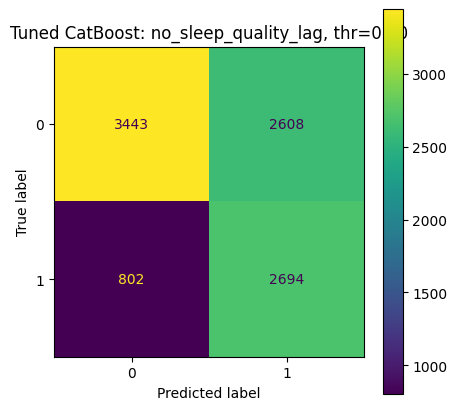

In [32]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax)
plt.title(f"Tuned CatBoost: no_sleep_quality_lag, thr={best_threshold:.2f}")
plt.savefig(
    CM_FIG_DIR / "catboost_tuned_no_sleep_quality_lag_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.get_feature_importance()
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
21,dur_spt_wake_IN_min_lag1,21.836380
44,dur_spt_wake_IN_min_lag2,16.524165
67,dur_spt_wake_IN_min_lag3,12.916186
66,dur_spt_sleep_min_lag3,7.960451
43,dur_spt_sleep_min_lag2,7.088039
20,dur_spt_sleep_min_lag1,4.212256
2,window_number,2.137002
45,dur_spt_wake_LIG_min_lag2,1.453329
68,dur_spt_wake_LIG_min_lag3,1.361185
26,dur_spt_min_lag1,1.359413


In [34]:
feature_importance.to_csv(
    REPORT_TABLES_DIR / "catboost_feature_importance_tuned_no_sleep_quality_lag.csv",
    index=False
)

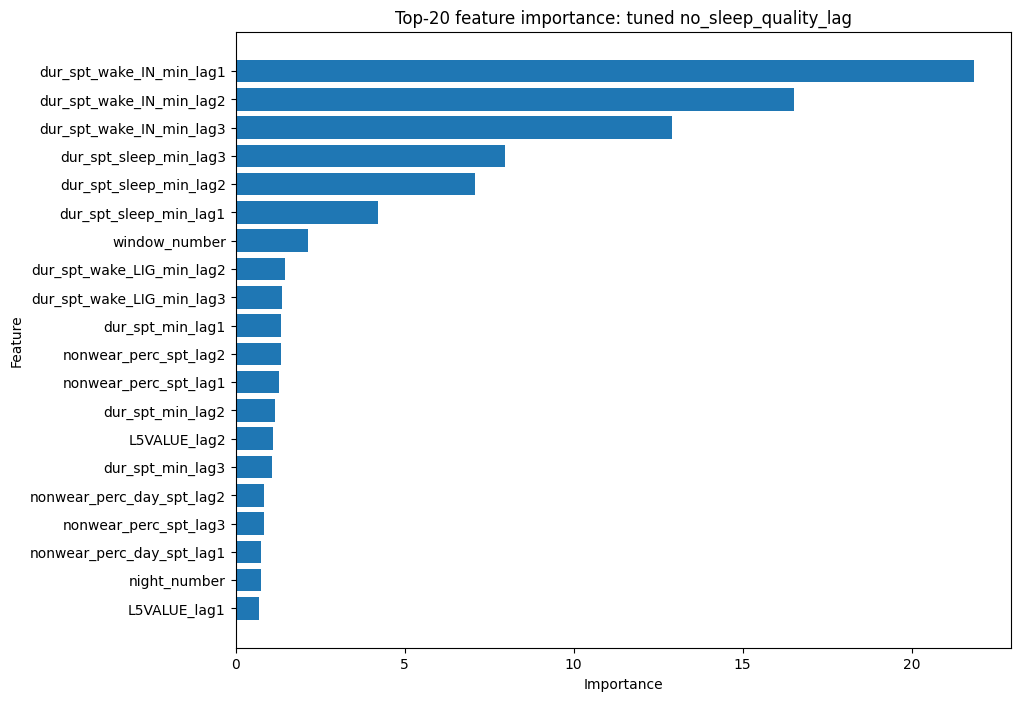

In [35]:
top_n = 20
fi_top = feature_importance.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title("Top-20 feature importance: tuned no_sleep_quality_lag")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig(
    FI_FIG_DIR / "catboost_tuned_no_sleep_quality_lag_top20.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [36]:
best_model.save_model(
    CATBOOST_MODEL_DIR / "catboost_tuned_no_sleep_quality_lag.cbm"
)

In [37]:
test_pred_df = X_test.copy()
test_pred_df["y_true"] = y_test.values
test_pred_df["y_proba"] = test_proba
test_pred_df["y_pred"] = test_pred

test_pred_df.to_csv(
    REPORT_TABLES_DIR / "catboost_test_predictions_tuned_no_sleep_quality_lag.csv",
    index=False
)

In [38]:
log_data = {
    "mode": "no_sleep_quality_lag",
    "best_params": {
        "depth": int(best_cfg["depth"]),
        "learning_rate": float(best_cfg["learning_rate"]),
        "l2_leaf_reg": float(best_cfg["l2_leaf_reg"]),
        "iterations": int(best_cfg["iterations"]),
    },
    "best_iteration": int(best_cfg["best_iteration"]),
    "best_threshold": float(best_threshold),
    "valid_roc_auc": float(best_cfg["valid_roc_auc"]),
    "valid_f1": float(best_cfg["valid_f1"]),
    "test_roc_auc": float(test_auc),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
}

with open(
    REPORT_LOGS_DIR / "run_tuned_no_sleep_quality_lag.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(log_data, f, ensure_ascii=False, indent=2)